In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Entregable.csv')

In [ ]:
# Empezamos viendo que tenemos en la tabla. Vemos cantidades muy dispares entre columnas
print(df.head())

   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   


In [ ]:
# Vemos que tenemos varias columnas con object, que debemos eliminar.
# Una columna booleana que debemos tratarla.
# Valores nulos en tres caracteristicas que debemos eliminar.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [ ]:
# Vemos los datos nulos

null_analysis = pd.DataFrame({
    'Total de Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Total de Nulos', ascending=False)
print(null_analysis[null_analysis['Total de Nulos'] > 0])

            Total de Nulos  Porcentaje (%)
artists                  1        0.000877
track_name               1        0.000877
album_name               1        0.000877


In [ ]:
# Tenemos datos duplicados?, en tal caso los eliminaremos.

num_duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Filas duplicadas: {num_duplicates}")
print("Filas totales:", len(df))


Filas duplicadas: 0
Filas totales: 114000


In [ ]:
# Eliminamos las columnas object y columnna unnamed

columnas_eliminadas = ['Unnamed: 0'] + list(df.select_dtypes(include=['object']).columns)
df_features = df.drop(columns=columnas_eliminadas, errors='ignore')
print("Columnas finales:\n", df_features.dtypes)

Columnas finales:
 popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
dtype: object


In [ ]:
# Vemos los datos nulos

null_analysis = pd.DataFrame({
    'Total de Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Total de Nulos', ascending=False)
print(null_analysis[null_analysis['Total de Nulos'] > 0])

            Total de Nulos  Porcentaje (%)
artists                  1        0.000877
track_name               1        0.000877
album_name               1        0.000877


In [ ]:
print("\n--- 2.4 Eliminación de Nulos (dropna()) ---")
# Guardamos los índices de las filas limpias que vamos a usar en el modelado.
original_indices = df_features.dropna().index
df_features_cleaned = df_features.loc[original_indices]

print("Filas finales listas para modelar:", len(df_features_cleaned))


--- 2.4 Eliminación de Nulos (dropna()) ---
Filas finales listas para modelar: 114000


In [ ]:
print(null_analysis[null_analysis['Total de Nulos'] > 0])

            Total de Nulos  Porcentaje (%)
artists                  1        0.000877
track_name               1        0.000877
album_name               1        0.000877


In [ ]:
# Pasamos la columna "explicit" a int

df_features['explicit'] = df_features['explicit'].astype(int)
original_indices = df_features.dropna().index
df_features_cleaned = df_features.loc[original_indices]

In [ ]:
original_indices = df_features.dropna().index
df_features_cleaned = df_features.loc[original_indices]
print("Filas para modelar:", len(df_features_cleaned))


Filas para modelar: 114000


In [ ]:
# Estandarizamos los datos

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features_cleaned.values)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_features_cleaned.columns)

print("Datos estandarizados:\n", X_scaled_df.head())

Datos estandarizados:
    popularity  duration_ms  explicit  danceability    energy       key  \
0    1.782627     0.024575 -0.305767      0.629244 -0.717148 -1.210442   
1    0.975633    -0.730859 -0.305767     -0.845908 -1.889980 -1.210442   
2    1.065299    -0.160332 -0.305767     -0.742186 -1.122669 -1.491343   
3    1.692961    -0.243214 -0.305767     -1.733304 -2.312994 -1.491343   
4    2.186125    -0.271919 -0.305767      0.295030 -0.788711 -0.929541   

   loudness      mode  speechiness  acousticness  instrumentalness  liveness  \
0  0.300828 -1.326281     0.551848     -0.850202         -0.504109  0.758743   
1 -1.784744  0.753988    -0.078993      1.831732         -0.504094 -0.591211   
2 -0.293288  0.753988    -0.273826     -0.315499         -0.504112 -0.507167   
3 -2.039252  0.753988    -0.457309      1.774593         -0.503883 -0.428376   
4 -0.282750  0.753988    -0.303145      0.463399         -0.504112 -0.686285   

    valence     tempo  time_signature  
0  0.929306


 GRAFICO T-SNE


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


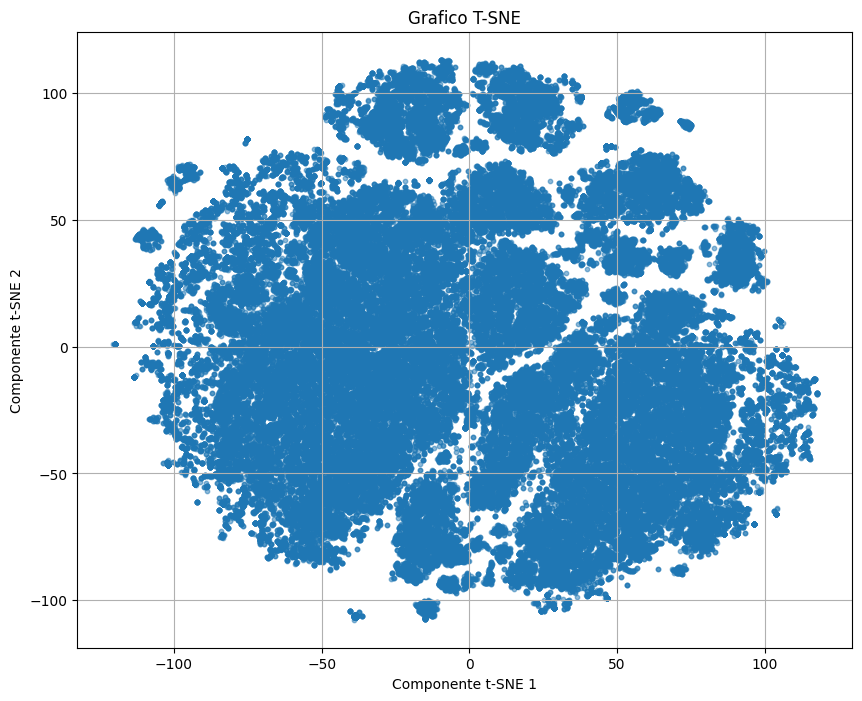

In [ ]:
# Aplicamos el modelo T-SNE

print("\n GRAFICO T-SNE")
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate='auto', init='random', n_iter=1000)
tsne_results = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(tsne_results, columns=['TSNE_1', 'TSNE_2'])
df_tsne_final = df_tsne.copy()

plt.figure(figsize=(10, 8))
plt.scatter(df_tsne_final['TSNE_1'], df_tsne_final['TSNE_2'], s=10, alpha=0.5)
plt.title('Grafico T-SNE')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.grid(True)
plt.show()



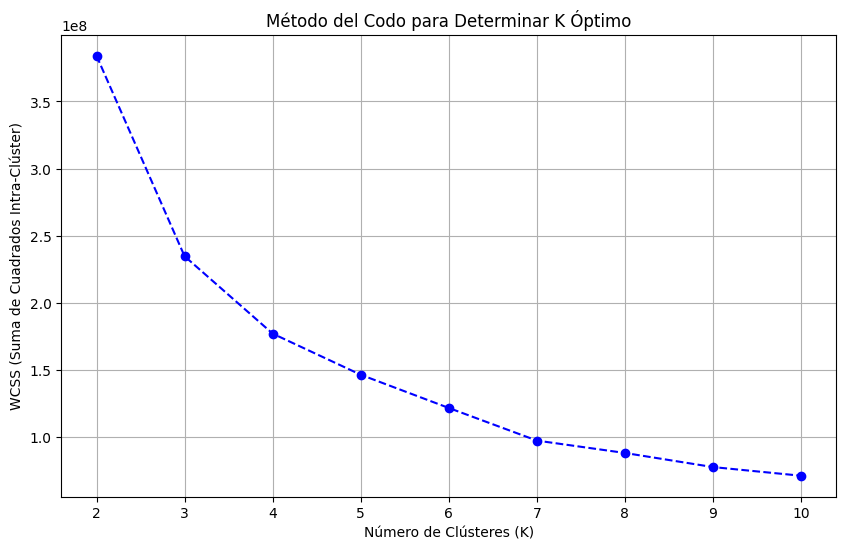

In [ ]:
# Elbow

wcss = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_tsne_final)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='blue')
plt.title('Método del Codo para Determinar K Óptimo')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('WCSS (Suma de Cuadrados Intra-Clúster)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Parece que el K óptimo se encuentra entre el 4 y el 5


Para K=2, el Coeficiente de Silueta es: 0.3664
Para K=3, el Coeficiente de Silueta es: 0.3989
Para K=4, el Coeficiente de Silueta es: 0.3720
Para K=5, el Coeficiente de Silueta es: 0.3372
Para K=6, el Coeficiente de Silueta es: 0.3618
Para K=7, el Coeficiente de Silueta es: 0.3784


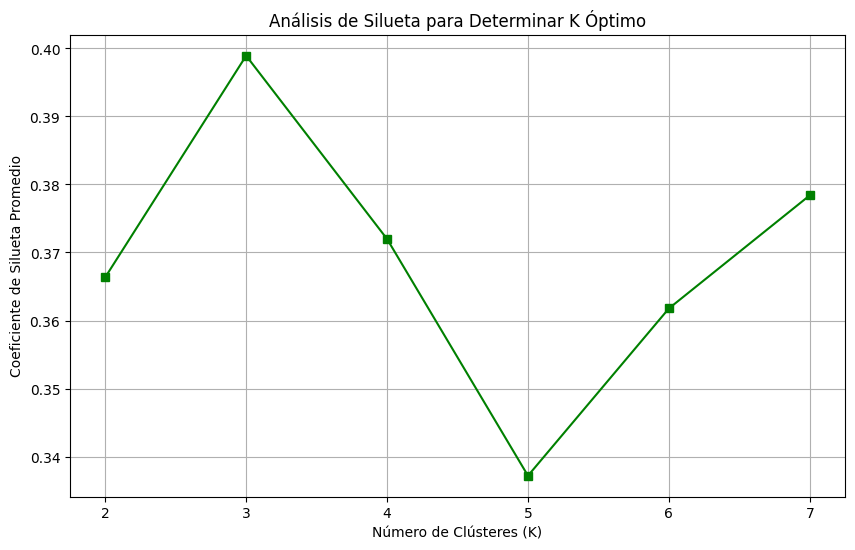

In [ ]:
from sklearn.cluster import KMeans

# Silhouette

silhouette_avg = []
k_range_sil = range(2, 8)

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(df_tsne_final)

    score = silhouette_score(df_tsne_final, cluster_labels)
    silhouette_avg.append(score)
    print(f"Para K={k}, el Coeficiente de Silueta es: {score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range_sil, silhouette_avg, marker='s', linestyle='-', color='green')
plt.title('Análisis de Silueta para Determinar K Óptimo')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Coeficiente de Silueta Promedio')
plt.xticks(k_range_sil)
plt.grid(True)
plt.show()


# Agrupar las canciones en 4 categorías es el punto ideal porque permite que cada grupo sea muy parecido entre sí, pero claramente distinto de los demás. Esta división evita confusiones entre estilos y ofrece una segmentación limpia y fácil de entender para cualquier decisión práctica